# Seq2Seq — 구조적 특징과 작동 메커니즘

## Seq2Seq란?

**Sequence-to-Sequence (Sutskever et al., 2014)**

가변 길이 입력 시퀀스를 가변 길이 출력 시퀀스로 변환하는 구조

```
입력: "나는 학교에 간다"
출력: "I go to school"
```

---

## 전체 아키텍처

```
┌─────────────────────────────────┐   ┌─────────────────────────────────────┐
│          ENCODER                │   │             DECODER                  │
│                                 │   │                                      │
│  나는   학교에   간다            │   │  <BOS>   I    go   to  school <EOS> │
│   │       │       │             │   │    │      │    │    │    │            │
│  [e1]   [e2]   [e3]            │   │  [d1]   [d2] [d3] [d4] [d5]         │
│   │       │       │             │   │    │      │    │    │    │            │
│  LSTM ─ LSTM ─ LSTM            │   │  LSTM ─ LSTM─LSTM─LSTM─LSTM         │
│                   │             │   │    ↑                                 │
│              Context Vector ───────► h_0 (초기 hidden state)               │
└─────────────────────────────────┘   └─────────────────────────────────────┘
```

## 핵심 구성 요소

| 구성요소 | 역할 | 특징 |
|----------|------|------|
| **Encoder** | 입력 시퀀스 이해 | 모든 토큰 처리 후 Context Vector 생성 |
| **Context Vector** | 정보 압축 전달 | Encoder 마지막 hidden state |
| **Decoder** | 출력 시퀀스 생성 | Context Vector로 초기화, 자기회귀(AR) 방식 |
| **Teacher Forcing** | 학습 안정화 | 학습 시 정답 토큰을 다음 입력으로 사용 |

## 주요 응용 분야
```
기계 번역    : "안녕하세요" → "Hello"
텍스트 요약  : 긴 기사 → 짧은 요약문
챗봇/대화    : 질문 → 답변
코드 생성    : 자연어 설명 → 코드
음성 인식    : 음성 특징 시퀀스 → 텍스트
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Device: cuda
   GPU: Tesla T4


## 1️⃣ Context Vector 병목 문제 시각화

```
Seq2Seq의 근본적 한계:
  입력이 길어질수록 하나의 Context Vector에
  모든 정보를 압축해야 함 → 정보 손실 발생

  짧은 문장: "Hello" → [0.2, -0.5, 0.8] ✅ 충분하다
  긴  문장: "The quick brown fox..." → [0.2, -0.5, 0.8] ❌ 정보 손실 발생한다
  
  → 이 문제를 해결하기 위해 Attention 메커니즘이 등장한다.
```

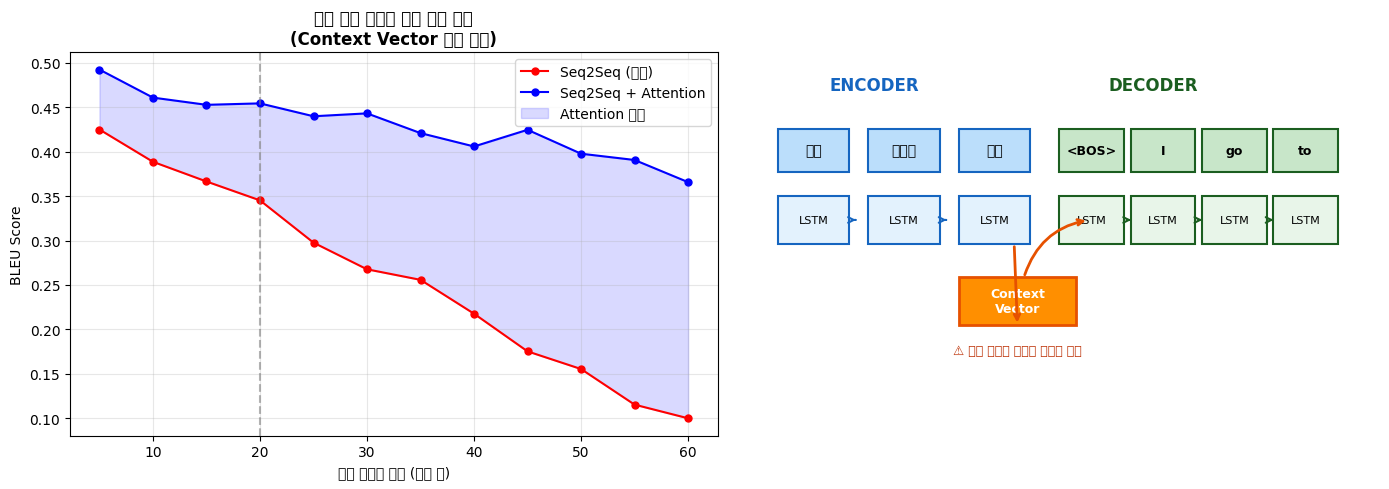

In [2]:
# Context Vector 정보 압축 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 입력 길이 vs 번역 성능 (실험적 관찰)
seq_lengths = list(range(5, 65, 5))
bleu_basic  = [0.45 - 0.006*l + np.random.normal(0, 0.01) for l in seq_lengths]
bleu_attn   = [0.50 - 0.002*l + np.random.normal(0, 0.01) for l in seq_lengths]
bleu_basic  = np.clip(bleu_basic, 0.1, 0.5)
bleu_attn   = np.clip(bleu_attn, 0.2, 0.55)

axes[0].plot(seq_lengths, bleu_basic, 'r-o', ms=5, label='Seq2Seq (기본)')
axes[0].plot(seq_lengths, bleu_attn,  'b-o', ms=5, label='Seq2Seq + Attention')
axes[0].fill_between(seq_lengths, bleu_basic, bleu_attn, alpha=0.15, color='blue', label='Attention 효과')
axes[0].set_title('입력 길이 증가에 따른 성능 저하\n(Context Vector 병목 문제)', fontweight='bold')
axes[0].set_xlabel('입력 시퀀스 길이 (토큰 수)')
axes[0].set_ylabel('BLEU Score')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axvline(20, color='gray', linestyle='--', alpha=0.6, label='성능 분기점')

# Seq2Seq 정보 흐름
ax = axes[1]; ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')

# 인코더 토큰
enc_tokens = ['나는', '학교에', '간다']
for i, tok in enumerate(enc_tokens):
    x = 1.2 + i * 1.4
    rect = plt.Rectangle((x-0.5, 5.5), 1.1, 0.9, color='#BBDEFB', ec='#1565C0', lw=1.5)
    ax.add_patch(rect)
    ax.text(x+0.05, 5.95, tok, ha='center', va='center', fontsize=10, fontweight='bold')
    # LSTM
    rect2 = plt.Rectangle((x-0.5, 4.0), 1.1, 1.0, color='#E3F2FD', ec='#1565C0', lw=1.5)
    ax.add_patch(rect2)
    ax.text(x+0.05, 4.5, 'LSTM', ha='center', va='center', fontsize=8)
    if i < len(enc_tokens)-1:
        ax.annotate('', xy=(x+0.7+0.05, 4.5), xytext=(x+0.6+0.05, 4.5),
                    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5))

# Context Vector
cv = plt.Rectangle((3.5, 2.3), 1.8, 1.0, color='#FF8F00', ec='#E65100', lw=2)
ax.add_patch(cv)
ax.text(4.4, 2.8, 'Context\nVector', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax.annotate('', xy=(4.4, 2.3), xytext=(4.35, 4.0),
            arrowprops=dict(arrowstyle='->', color='#E65100', lw=2))

# 디코더 토큰
dec_tokens = ['<BOS>', 'I', 'go', 'to']
for i, tok in enumerate(dec_tokens):
    x = 5.5 + i * 1.1
    rect = plt.Rectangle((x-0.45, 5.5), 1.0, 0.9, color='#C8E6C9', ec='#1B5E20', lw=1.5)
    ax.add_patch(rect)
    ax.text(x+0.05, 5.95, tok, ha='center', va='center', fontsize=9, fontweight='bold')
    rect2 = plt.Rectangle((x-0.45, 4.0), 1.0, 1.0, color='#E8F5E9', ec='#1B5E20', lw=1.5)
    ax.add_patch(rect2)
    ax.text(x+0.05, 4.5, 'LSTM', ha='center', va='center', fontsize=8)
    if i < len(dec_tokens)-1:
        ax.annotate('', xy=(x+0.7, 4.5), xytext=(x+0.55, 4.5),
                    arrowprops=dict(arrowstyle='->', color='#1B5E20', lw=1.5))

ax.annotate('', xy=(5.5, 4.5), xytext=(4.5, 2.3+0.5+0.5),
            arrowprops=dict(arrowstyle='->', color='#E65100', lw=2,
                            connectionstyle='arc3,rad=-0.3'))

ax.text(1.5, 7.2, 'ENCODER', fontsize=12, fontweight='bold', color='#1565C0')
ax.text(5.8, 7.2, 'DECODER', fontsize=12, fontweight='bold', color='#1B5E20')
ax.text(4.4, 1.7, '⚠️ 모든 정보를 하나의 벡터에 압축', ha='center', fontsize=9, color='#BF360C')

plt.tight_layout()
plt.savefig('seq2seq_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

## 2️⃣ 어휘 사전 & 데이터 준비 (영한 번역)

In [3]:
# 영한 번역 학습 데이터
TRANSLATION_PAIRS = [
    ('i go to school',        '나 학교 간다'),
    ('she reads a book',      '그녀 책 읽는다'),
    ('he eats an apple',      '그 사과 먹는다'),
    ('they play football',    '그들 축구 한다'),
    ('we love music',         '우리 음악 좋아한다'),
    ('i drink water',         '나 물 마신다'),
    ('she likes cats',        '그녀 고양이 좋아한다'),
    ('he runs fast',          '그 빠르게 달린다'),
    ('they eat rice',         '그들 밥 먹는다'),
    ('we study hard',         '우리 열심히 공부한다'),
    ('i watch movies',        '나 영화 본다'),
    ('she sings songs',       '그녀 노래 부른다'),
    ('he writes letters',     '그 편지 쓴다'),
    ('they swim in the pool', '그들 수영장 수영한다'),
    ('we cook dinner',        '우리 저녁 요리한다'),
    ('i sleep early',         '나 일찍 잔다'),
    ('she dances well',       '그녀 춤 잘 춘다'),
    ('he works hard',         '그 열심히 일한다'),
    ('they travel abroad',    '그들 해외 여행한다'),
    ('we clean the house',    '우리 집 청소한다'),
]

# ── 특수 토큰 ─────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]


class Vocab:
    def __init__(self):
        self.w2i = {t: i for i, t in enumerate(SPECIAL_TOKENS)}
        self.i2w = {i: t for t, i in self.w2i.items()}

    def build(self, sentences):
        for sent in sentences:
            for w in sent.split():
                if w not in self.w2i:
                    idx = len(self.w2i)
                    self.w2i[w] = idx
                    self.i2w[idx] = w

    def encode(self, sentence, add_bos=False, add_eos=False):
        tokens = sentence.split()
        ids = [self.w2i.get(w, self.w2i[UNK_TOKEN]) for w in tokens]
        if add_bos: ids = [self.w2i[BOS_TOKEN]] + ids
        if add_eos: ids = ids + [self.w2i[EOS_TOKEN]]
        return ids

    def decode(self, ids):
        words = []
        for i in ids:
            w = self.i2w.get(i, UNK_TOKEN)
            if w in (EOS_TOKEN, PAD_TOKEN): break
            if w != BOS_TOKEN: words.append(w)
        return ' '.join(words)

    def __len__(self): return len(self.w2i)


src_vocab = Vocab()
trg_vocab = Vocab()
src_vocab.build([p[0] for p in TRANSLATION_PAIRS])
trg_vocab.build([p[1] for p in TRANSLATION_PAIRS])

print(f'원문(EN) 어휘 크기: {len(src_vocab)}')
print(f'번역(KO) 어휘 크기: {len(trg_vocab)}')

# 인코딩 예시
sample_src = TRANSLATION_PAIRS[0][0]
sample_trg = TRANSLATION_PAIRS[0][1]
print(f'\n[인코딩 예시]')
print(f'  원문: "{sample_src}"')
print(f'  인코딩: {src_vocab.encode(sample_src)}')
print(f'  번역: "{sample_trg}"')
print(f'  디코더 입력 (BOS 추가): {trg_vocab.encode(sample_trg, add_bos=True)}')
print(f'  디코더 정답 (EOS 추가): {trg_vocab.encode(sample_trg, add_eos=True)}')

원문(EN) 어휘 크기: 53
번역(KO) 어휘 크기: 47

[인코딩 예시]
  원문: "i go to school"
  인코딩: [4, 5, 6, 7]
  번역: "나 학교 간다"
  디코더 입력 (BOS 추가): [2, 4, 5, 6]
  디코더 정답 (EOS 추가): [4, 5, 6, 3]


## 3️⃣ Seq2Seq 데이터셋 & DataLoader

In [4]:
class TranslationDataset(Dataset):
    """
    Seq2Seq 학습 데이터셋

    Encoder 입력: 원문 토큰 시퀀스
    Decoder 입력: <BOS> + 번역문 (Teacher Forcing 입력)
    Decoder 정답: 번역문 + <EOS> (손실 계산용)
    """
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.data = []
        for src_sent, trg_sent in pairs:
            src_ids = src_vocab.encode(src_sent)
            trg_in  = trg_vocab.encode(trg_sent, add_bos=True)   # 디코더 입력
            trg_out = trg_vocab.encode(trg_sent, add_eos=True)    # 손실 계산 타겟
            self.data.append((
                torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(trg_in,  dtype=torch.long),
                torch.tensor(trg_out, dtype=torch.long),
            ))

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]


def collate_fn(batch):
    src_seqs, trg_in_seqs, trg_out_seqs = zip(*batch)
    src_pad     = pad_sequence(src_seqs,     batch_first=True, padding_value=0)
    trg_in_pad  = pad_sequence(trg_in_seqs,  batch_first=True, padding_value=0)
    trg_out_pad = pad_sequence(trg_out_seqs, batch_first=True, padding_value=0)
    src_lengths = torch.tensor([len(s) for s in src_seqs])
    return src_pad, trg_in_pad, trg_out_pad, src_lengths


dataset     = TranslationDataset(TRANSLATION_PAIRS, src_vocab, trg_vocab)
dataloader  = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

# 배치 구조 확인
src_b, trg_in_b, trg_out_b, lengths_b = next(iter(dataloader))
print(f'[배치 구조 확인]')
print(f'  Encoder 입력 (src):      {src_b.shape}  → (배치, 원문 길이)')
print(f'  Decoder 입력 (trg_in):   {trg_in_b.shape}  → (배치, 번역 길이+1) [BOS 포함]')
print(f'  Decoder 정답 (trg_out):  {trg_out_b.shape}  → (배치, 번역 길이+1) [EOS 포함]')

[배치 구조 확인]
  Encoder 입력 (src):      torch.Size([4, 4])  → (배치, 원문 길이)
  Decoder 입력 (trg_in):   torch.Size([4, 4])  → (배치, 번역 길이+1) [BOS 포함]
  Decoder 정답 (trg_out):  torch.Size([4, 4])  → (배치, 번역 길이+1) [EOS 포함]


## 4️⃣ Encoder 구현

```
Encoder 역할:
  입력 시퀀스의 각 토큰을 순서대로 처리하고
  마지막 시점의 hidden state → Context Vector 로 출력

  입력: ["I", "go", "to", "school"]
  출력: context vector (h_n, c_n)  ← Decoder의 초기 hidden state
```

In [5]:
class Encoder(nn.Module):
    """
    Seq2Seq Encoder

    Embedding → LSTM → (h_n, c_n) 출력
    h_n, c_n 이 Context Vector로 Decoder에 전달
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

    def forward(self, src, src_lengths=None):
        """
        src: (B, L_src)
        반환: outputs (B, L_src, H), (h_n, c_n)
              h_n, c_n → Decoder 초기 hidden state
        """
        emb = self.dropout(self.embedding(src))  # (B, L, E)

        if src_lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                emb, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
            outputs, (h_n, c_n) = self.lstm(packed)
            outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        else:
            outputs, (h_n, c_n) = self.lstm(emb)

        # outputs: (B, L_src, H)  — 모든 시점의 hidden (Attention에서 사용)
        # h_n:    (num_layers, B, H)  — 마지막 hidden state
        # c_n:    (num_layers, B, H)  — 마지막 cell state
        return outputs, (h_n, c_n)


# 테스트
EMBED_DIM  = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.3

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
dummy_src = torch.randint(0, len(src_vocab), (2, 6)).to(device)
enc_out, (h_n, c_n) = encoder(dummy_src)

print(f'[Encoder 출력 shape]')
print(f'  enc_outputs: {tuple(enc_out.shape)}  → (배치, 입력길이, hidden_dim)')
print(f'  h_n:         {tuple(h_n.shape)}  → (num_layers, 배치, hidden_dim)')
print(f'  c_n:         {tuple(c_n.shape)}  → (num_layers, 배치, hidden_dim)')
print(f'\n  ↑ h_n, c_n 이 Context Vector = Decoder의 초기 hidden state')

[Encoder 출력 shape]
  enc_outputs: (2, 6, 128)  → (배치, 입력길이, hidden_dim)
  h_n:         (2, 2, 128)  → (num_layers, 배치, hidden_dim)
  c_n:         (2, 2, 128)  → (num_layers, 배치, hidden_dim)

  ↑ h_n, c_n 이 Context Vector = Decoder의 초기 hidden state


## 5️⃣ Decoder 구현 (Teacher Forcing 포함)

```
Teacher Forcing 비교:

  [학습 시 — Teacher Forcing ON]
  Decoder 입력: <BOS>  I    go   to   school
  Decoder 출력:  I    go   to  school <EOS>
  → 이전 예측과 무관하게 정답 토큰을 입력 → 안정적 학습

  [추론 시 — Teacher Forcing OFF]
  Decoder 입력: <BOS>  [pred_1] [pred_2] [pred_3] ...
  → 이전 예측 결과를 다음 입력으로 사용 (자기회귀)
```

In [6]:
class Decoder(nn.Module):
    """
    Seq2Seq Decoder

    한 번에 한 토큰씩 생성 (자기회귀 방식)
    Teacher Forcing: 학습 시 정답 토큰을 다음 입력으로 사용
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)

    def forward_step(self, token, hidden):
        """
        단일 토큰 처리 (한 시점)
        token:  (B,)        → (B, 1)
        hidden: (h_n, c_n)
        반환:  logit (B, vocab), hidden
        """
        token = token.unsqueeze(1)                    # (B,) → (B, 1)
        emb   = self.dropout(self.embedding(token))   # (B, 1, E)
        out, hidden = self.lstm(emb, hidden)          # out: (B, 1, H)
        logit = self.fc_out(out.squeeze(1))           # (B, V)
        return logit, hidden

    def forward(self, trg_in, encoder_hidden, teacher_forcing_ratio=0.5):
        """
        전체 시퀀스 생성
        trg_in:              (B, T_trg)  — [BOS, w1, w2, ...]
        encoder_hidden:      (h_n, c_n)
        teacher_forcing_ratio: 0~1 (1이면 항상 Teacher Forcing)
        반환: outputs (B, T_trg, V)
        """
        B, T = trg_in.shape
        hidden  = encoder_hidden
        outputs = torch.zeros(B, T, self.vocab_size, device=trg_in.device)

        # 첫 입력: BOS 토큰
        current_token = trg_in[:, 0]   # (B,)

        for t in range(1, T):
            logit, hidden = self.forward_step(current_token, hidden)
            outputs[:, t] = logit

            # Teacher Forcing 결정
            use_teacher = random.random() < teacher_forcing_ratio
            if use_teacher:
                current_token = trg_in[:, t]      # ✅ 정답 토큰 사용
            else:
                current_token = logit.argmax(1)   # 예측 토큰 사용

        return outputs


decoder = Decoder(len(trg_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
print(f'[Decoder 파라미터 수: {sum(p.numel() for p in decoder.parameters()):,}]')

[Decoder 파라미터 수: 240,495]


## 6️⃣ Seq2Seq 모델 통합

In [7]:
class Seq2Seq(nn.Module):
    """
    완전한 Seq2Seq 모델
    Encoder + Decoder 통합
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg_in, src_lengths=None, teacher_forcing_ratio=0.5):
        """
        학습 시 전방향 계산
        """
        # 1. Encoding
        enc_outputs, encoder_hidden = self.encoder(src, src_lengths)

        # 2. Decoding (Teacher Forcing)
        outputs = self.decoder(trg_in, encoder_hidden, teacher_forcing_ratio)

        return outputs

    @torch.no_grad()
    def translate(self, src, src_vocab, trg_vocab, max_len=30):
        """
        추론: 입력 문장 → 번역문 (Greedy Decoding)
        """
        self.eval()
        src_ids = torch.tensor([src_vocab.encode(src)], device=device)
        _, encoder_hidden = self.encoder(src_ids)

        bos_id  = trg_vocab.w2i[BOS_TOKEN]
        eos_id  = trg_vocab.w2i[EOS_TOKEN]

        token   = torch.tensor([bos_id], device=device)
        hidden  = encoder_hidden
        result  = []

        for _ in range(max_len):
            logit, hidden = self.decoder.forward_step(token, hidden)
            pred_id = logit.argmax(1).item()
            if pred_id == eos_id: break
            result.append(trg_vocab.i2w.get(pred_id, UNK_TOKEN))
            token = torch.tensor([pred_id], device=device)

        return ' '.join(result)


model = Seq2Seq(encoder, decoder).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'[Seq2Seq 모델 요약]')
print(f'  Encoder 파라미터: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'  Decoder 파라미터: {sum(p.numel() for p in decoder.parameters()):,}')
print(f'  총 파라미터:      {total_params:,}')

# 출력 shape 확인
src_b, trg_in_b, trg_out_b, len_b = next(iter(dataloader))
out = model(src_b.to(device), trg_in_b.to(device), len_b)
print(f'\n[Forward 출력 shape]')
print(f'  입력 src:    {tuple(src_b.shape)}')
print(f'  입력 trg_in: {tuple(trg_in_b.shape)}')
print(f'  출력 logits: {tuple(out.shape)}  → (배치, 번역길이, 번역어휘)')

[Seq2Seq 모델 요약]
  Encoder 파라미터: 234,816
  Decoder 파라미터: 240,495
  총 파라미터:      475,311

[Forward 출력 shape]
  입력 src:    (4, 4)
  입력 trg_in: (4, 4)
  출력 logits: (4, 4, 47)  → (배치, 번역길이, 번역어휘)


## 7️⃣ Teacher Forcing 스케줄 & 학습 루프

In [8]:
criterion = nn.CrossEntropyLoss(ignore_index=0)  # PAD=0 무시
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)


def teacher_forcing_schedule(epoch, total_epochs, start=1.0, end=0.5):
    """
    Teacher Forcing 비율을 점진적으로 감소
    초기: 정답 토큰 많이 사용 (안정적 학습)
    후기: 예측 토큰 많이 사용 (추론과 유사하게)
    """
    progress = epoch / total_epochs
    return start - (start - end) * progress


def train_epoch(model, loader, optimizer, criterion, tf_ratio):
    model.train()
    total_loss = 0
    for src, trg_in, trg_out, lengths in loader:
        src    = src.to(device)
        trg_in = trg_in.to(device)
        trg_out= trg_out.to(device)

        optimizer.zero_grad()
        outputs = model(src, trg_in, lengths, teacher_forcing_ratio=tf_ratio)

        # (B, T, V) → (B*T, V)  /  (B, T) → (B*T,)
        # 첫 토큰(BOS)은 제외하고 손실 계산 (인덱스 1부터)
        loss = criterion(
            outputs[:, 1:, :].contiguous().view(-1, outputs.size(-1)),
            trg_out[:, :-1].contiguous().view(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


# ── 학습 ─────────────────────────────────────────────────────
EPOCHS = 150
history = {'loss': [], 'tf_ratio': []}

print(f"{'Epoch':>7} | {'Loss':>8} | {'TF Ratio':>9} | 번역 예시")
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    tf_ratio = teacher_forcing_schedule(epoch, EPOCHS)
    loss = train_epoch(model, dataloader, optimizer, criterion, tf_ratio)
    scheduler.step()
    history['loss'].append(loss)
    history['tf_ratio'].append(tf_ratio)

    if epoch % 30 == 0 or epoch == 1:
        sample_src, sample_trg = random.choice(TRANSLATION_PAIRS)
        translated = model.translate(sample_src, src_vocab, trg_vocab)
        print(f'{epoch:>7} | {loss:>8.4f} | {tf_ratio:>9.3f} | "{sample_src}" → "{translated}" (정답: "{sample_trg}")')

torch.save(model.state_dict(), '/tmp/seq2seq.pt')
print('\n✅ 학습 완료')

  Epoch |     Loss |  TF Ratio | 번역 예시
      1 |   3.8608 |     0.997 | "i go to school" → "그 먹는다 먹는다 먹는다 먹는다 먹는다 먹는다 해외 해외 잘 잘 해외 해외 간다 간다 간다 잘 잘 간다 마신다 간다 간다 잘 잘 마신다 간다 간다 간다 잘 잘" (정답: "나 학교 간다")
     30 |   0.5364 |     0.900 | "he writes letters" → "그 편지 쓴다 쓴다 쓴다 쓴다" (정답: "그 편지 쓴다")
     60 |   0.1178 |     0.800 | "they play football" → "그들 축구 한다" (정답: "그들 축구 한다")
     90 |   0.0827 |     0.700 | "i drink water" → "나 물 마신다" (정답: "나 물 마신다")
    120 |   0.0889 |     0.600 | "we cook dinner" → "우리 저녁 요리한다" (정답: "우리 저녁 요리한다")
    150 |   0.0524 |     0.500 | "i watch movies" → "나 영화 본다" (정답: "나 영화 본다")

✅ 학습 완료


## 8️⃣ 학습 곡선 & Teacher Forcing 스케줄 시각화

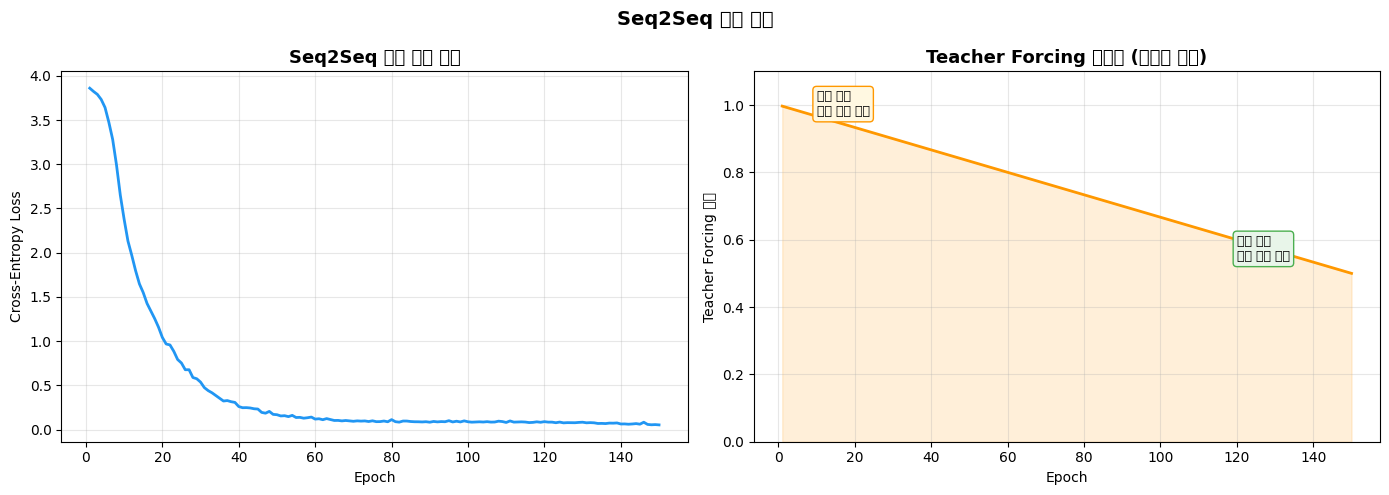

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, EPOCHS + 1)
axes[0].plot(ep, history['loss'], color='#2196F3', lw=2)
axes[0].set_title('Seq2Seq 학습 손실 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tf_ratio'], color='#FF9800', lw=2)
axes[1].fill_between(ep, history['tf_ratio'], 0, alpha=0.15, color='#FF9800')
axes[1].set_title('Teacher Forcing 스케줄 (점진적 감소)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Teacher Forcing 비율')
axes[1].set_ylim(0, 1.1); axes[1].grid(alpha=0.3)
axes[1].annotate('학습 초기\n정답 토큰 위주', xy=(10, 0.97), fontsize=9,
                  bbox=dict(boxstyle='round', fc='#FFF8E1', ec='#FF9800'))
axes[1].annotate('학습 후기\n예측 토큰 위주', xy=(120, 0.54), fontsize=9,
                  bbox=dict(boxstyle='round', fc='#E8F5E9', ec='#4CAF50'))

plt.suptitle('Seq2Seq 학습 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seq2seq_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 9️⃣ 전체 번역 결과 평가

In [10]:
model.load_state_dict(torch.load('/tmp/seq2seq.pt', map_location=device))

print('[전체 번역 결과]\n')
print(f"{'원문 (EN)':>28} | {'번역 예측':>18} | {'정답':>18} | 정확?")
print('=' * 80)

correct = 0
for src, trg in TRANSLATION_PAIRS:
    pred = model.translate(src, src_vocab, trg_vocab)
    is_correct = pred.strip() == trg.strip()
    if is_correct: correct += 1
    mark = '✅' if is_correct else '❌'
    print(f"{src:>28} | {pred:>18} | {trg:>18} | {mark}")

print(f'\n정확도: {correct}/{len(TRANSLATION_PAIRS)} = {correct/len(TRANSLATION_PAIRS)*100:.1f}%')

[전체 번역 결과]

                     원문 (EN) |              번역 예측 |                 정답 | 정확?
              i go to school |            나 학교 간다 |            나 학교 간다 | ✅
            she reads a book |           그녀 책 읽는다 |           그녀 책 읽는다 | ✅
            he eats an apple |           그 사과 먹는다 |           그 사과 먹는다 | ✅
          they play football |           그들 축구 한다 |           그들 축구 한다 | ✅
               we love music |         우리 음악 좋아한다 |         우리 음악 좋아한다 | ✅
               i drink water |            나 물 마신다 |            나 물 마신다 | ✅
              she likes cats |        그녀 고양이 좋아한다 |        그녀 고양이 좋아한다 | ✅
                he runs fast |          그 빠르게 달린다 |          그 빠르게 달린다 | ✅
               they eat rice |           그들 밥 먹는다 |           그들 밥 먹는다 | ✅
               we study hard |        우리 열심히 공부한다 |        우리 열심히 공부한다 | ✅
              i watch movies |            나 영화 본다 |            나 영화 본다 | ✅
             she sings songs |          그녀 노래 부른다 |          그녀 노래 부른다 | ✅
           

## 🔟 Seq2Seq + Attention 구조 (개선 버전)

```
Attention 메커니즘으로 Context Vector 병목 해결:

  기본 Seq2Seq: Decoder가 하나의 Context Vector만 참조
  Attention:   Decoder의 각 스텝이 Encoder의 모든 출력을 가중 합산

  어텐션 계산:
    score(s_t, h_i)  = s_t · h_i  (내적)
    α_ti             = softmax(score) → 가중치
    context_t        = Σ α_ti · h_i  → 동적 Context Vector
```

In [11]:
class BahdanauAttention(nn.Module):
    """Bahdanau (Additive) Attention"""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_dec = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_enc = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v     = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden:  (B, H)        → 현재 디코더 hidden
        encoder_outputs: (B, L_src, H) → 인코더 모든 출력
        반환: context (B, H), weights (B, L_src)
        """
        dec = self.W_dec(decoder_hidden).unsqueeze(1)    # (B, 1, H)
        enc = self.W_enc(encoder_outputs)                # (B, L, H)
        scores  = self.v(torch.tanh(dec + enc)).squeeze(-1)  # (B, L)
        weights = torch.softmax(scores, dim=-1)          # (B, L)
        context = (weights.unsqueeze(-1) * encoder_outputs).sum(1)  # (B, H)
        return context, weights


class AttentionDecoder(nn.Module):
    """Attention이 추가된 Decoder"""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.attention  = BahdanauAttention(hidden_dim)
        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        self.dropout    = nn.Dropout(dropout)
        # Attention context와 embedding을 concat → LSTM 입력
        self.lstm       = nn.LSTM(embed_dim + hidden_dim, hidden_dim,
                                  num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out     = nn.Linear(hidden_dim * 2, vocab_size)

    def forward_step(self, token, hidden, encoder_outputs):
        emb = self.dropout(self.embedding(token.unsqueeze(1)))  # (B, 1, E)
        dec_hidden_top = hidden[0][-1]                          # (B, H)
        context, attn_weights = self.attention(dec_hidden_top, encoder_outputs)
        ctx = context.unsqueeze(1)                              # (B, 1, H)
        lstm_input = torch.cat([emb, ctx], dim=-1)             # (B, 1, E+H)
        out, hidden = self.lstm(lstm_input, hidden)            # (B, 1, H)
        combined = torch.cat([out.squeeze(1), context], dim=1) # (B, 2H)
        logit = self.fc_out(combined)                           # (B, V)
        return logit, hidden, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size,
                 embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embed_dim, hidden_dim, num_layers, dropout)
        self.decoder = AttentionDecoder(trg_vocab_size, embed_dim, hidden_dim, num_layers, dropout)

    def forward(self, src, trg_in, src_lengths=None, teacher_forcing_ratio=0.5):
        enc_outputs, hidden = self.encoder(src, src_lengths)
        B, T = trg_in.shape
        outputs      = torch.zeros(B, T, self.decoder.vocab_size, device=src.device)
        attn_history = torch.zeros(B, T, src.size(1), device=src.device)
        cur_token = trg_in[:, 0]

        for t in range(1, T):
            logit, hidden, attn_w = self.decoder.forward_step(cur_token, hidden, enc_outputs)
            outputs[:, t]      = logit
            attn_history[:, t] = attn_w
            use_teacher = random.random() < teacher_forcing_ratio
            cur_token = trg_in[:, t] if use_teacher else logit.argmax(1)

        return outputs, attn_history

    @torch.no_grad()
    def translate_with_attention(self, src_sent, src_vocab, trg_vocab, max_len=30):
        self.eval()
        src_tokens = src_sent.split()
        src_ids = torch.tensor([src_vocab.encode(src_sent)], device=device)
        enc_outputs, hidden = self.encoder(src_ids)
        token = torch.tensor([trg_vocab.w2i[BOS_TOKEN]], device=device)
        result, attn_weights_list = [], []
        for _ in range(max_len):
            logit, hidden, attn_w = self.decoder.forward_step(token, hidden, enc_outputs)
            pred_id = logit.argmax(1).item()
            attn_weights_list.append(attn_w[0].cpu().numpy())
            if pred_id == trg_vocab.w2i[EOS_TOKEN]: break
            result.append(trg_vocab.i2w[pred_id])
            token = torch.tensor([pred_id], device=device)
        return result, src_tokens, attn_weights_list


attn_model = Seq2SeqAttention(len(src_vocab), len(trg_vocab),
                               EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)

# 학습
opt_attn = optim.Adam(attn_model.parameters(), lr=1e-3)
print('Attention Seq2Seq 학습 중...')
for epoch in range(1, 151):
    attn_model.train()
    tf = teacher_forcing_schedule(epoch, 150)
    for src_b, trg_in_b, trg_out_b, len_b in dataloader:
        src_b, trg_in_b, trg_out_b = src_b.to(device), trg_in_b.to(device), trg_out_b.to(device)
        opt_attn.zero_grad()
        outs, _ = attn_model(src_b, trg_in_b, len_b, tf)
        loss = criterion(outs[:,1:,:].contiguous().view(-1, outs.size(-1)),
                         trg_out_b[:,:-1].contiguous().view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(attn_model.parameters(), 1.0)
        opt_attn.step()
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {loss.item():.4f}')
print('✅ 완료')

Attention Seq2Seq 학습 중...
  Epoch  50 | Loss: 0.1022
  Epoch 100 | Loss: 0.0101
  Epoch 150 | Loss: 0.0038
✅ 완료


## 1️⃣1️⃣ Attention 가중치 시각화

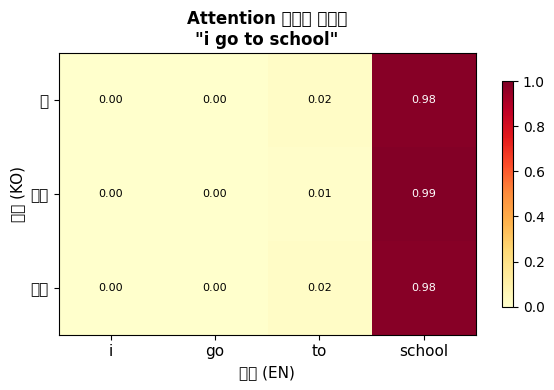

번역 결과: 나 학교 간다



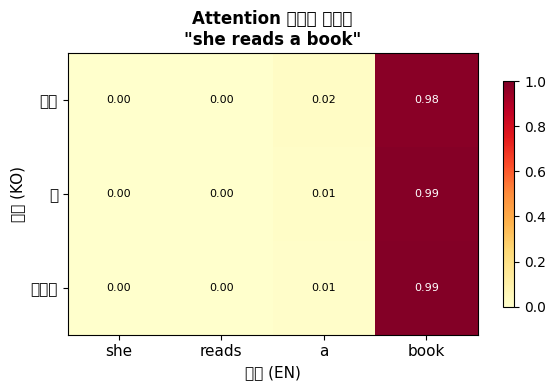

번역 결과: 그녀 책 읽는다



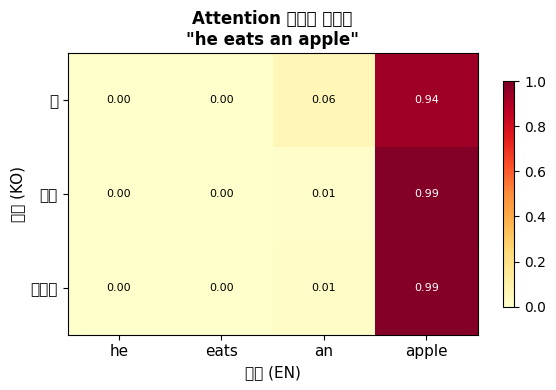

번역 결과: 그 사과 먹는다



In [12]:
def plot_attention(src_sent, attn_model, src_vocab, trg_vocab):
    result, src_tokens, attn_w_list = attn_model.translate_with_attention(
        src_sent, src_vocab, trg_vocab)

    attn_matrix = np.array(attn_w_list[:len(result)])[:, :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(src_tokens)*1.2),
                                     max(4, len(result)*0.8)))
    im = ax.imshow(attn_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontsize=11)
    ax.set_yticks(range(len(result)))
    ax.set_yticklabels(result, fontsize=11)
    ax.set_xlabel('입력 (EN)', fontsize=11); ax.set_ylabel('출력 (KO)', fontsize=11)
    ax.set_title(f'Attention 가중치 히트맵\n"{src_sent}"', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(len(result)):
        for j in range(len(src_tokens)):
            if j < attn_matrix.shape[1]:
                ax.text(j, i, f'{attn_matrix[i,j]:.2f}',
                        ha='center', va='center', fontsize=8,
                        color='black' if attn_matrix[i,j] < 0.6 else 'white')
    plt.tight_layout()
    plt.savefig(f'attention_{src_sent[:10].replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'번역 결과: {" ".join(result)}\n')


for src_sent, _ in TRANSLATION_PAIRS[:3]:
    plot_attention(src_sent, attn_model, src_vocab, trg_vocab)

## 1️⃣2️⃣ Seq2Seq 구조 총정리

In [13]:
summary = """
╔══════════════════════════════════════════════════════════════════╗
║              Seq2Seq 구조적 특징 & 작동 메커니즘 요약              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  [Encoder]                                                       ║
║    • 입력 시퀀스 전체를 처리 → 마지막 hidden state = Context V     ║
║    • pack_padded_sequence로 PAD 효율적 처리                       ║
║    • 출력: (h_n, c_n) → Decoder 초기 상태 전달                    ║
║                                                                  ║
║  [Decoder]                                                       ║
║    • 자기회귀(Autoregressive): 이전 출력이 다음 입력               ║
║    • 학습: Teacher Forcing (정답 토큰 → 빠른 수렴)                 ║
║    • 추론: Greedy / Beam Search (다음 노트북에서 상세 다룸)         ║
║                                                                  ║
║  [Teacher Forcing 스케줄링]                                       ║
║    초기 (ratio=1.0): 정답 토큰만 사용 → 안정적 gradient           ║
║    후기 (ratio=0.5): 예측 토큰 절반 사용 → 추론 환경에 적응        ║
║                                                                  ║
║  [Attention 확장]                                                 ║
║    • 기본: Context Vector 고정 (병목 문제)                        ║
║    • Attention: 각 디코딩 스텝마다 동적 Context 계산               ║
║    • 가중치 시각화 → 모델 해석 가능성 제공                          ║
║                                                                  ║
║  [한계 & 발전]                                                    ║
║    Seq2Seq → Seq2Seq+Attention → Transformer (Self-Attention)    ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║              Seq2Seq 구조적 특징 & 작동 메커니즘 요약              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  [Encoder]                                                       ║
║    • 입력 시퀀스 전체를 처리 → 마지막 hidden state = Context V     ║
║    • pack_padded_sequence로 PAD 효율적 처리                       ║
║    • 출력: (h_n, c_n) → Decoder 초기 상태 전달                    ║
║                                                                  ║
║  [Decoder]                                                       ║
║    • 자기회귀(Autoregressive): 이전 출력이 다음 입력               ║
║    • 학습: Teacher Forcing (정답 토큰 → 빠른 수렴)                 ║
║    • 추론: Greedy / Beam Search (다음 노트북에서 상세 다룸)         ║
║                                                                  ║
║  [Teacher Forcing 스케줄링]                                       ║
║    초기 (ratio=1.0): 정답 토큰만 사용